In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import ndimage as ndi
from ase import io as aio
import abtem

from gas.PDFs.RDFs import RDF
from gas.PDFs.RDF_2D import RDF_2D
from gas.PDFs.PDF_3body import PDF3B
from gas.PDFs.PDFs_utils.PDF_show import plot_RDF3b, plot_r1r2_RDF3b
from gas.io.xyz import load_xyz
from datetime import datetime 


try:
    import cupy as cp
    if cp.cuda.is_available():
        print(f"Found {cp.cuda.runtime.getDeviceCount()} GPUs")
        device = 1
        print(f"Will use GPU {device}")
        cp.cuda.Device(device).use()
    else:
        print("No GPUs found, using CPU")
        device='cpu'
except (ImportError, ModuleNotFoundError):
    print("No GPUs found, using CPU")
    device='cpu'

Found 4 GPUs
Will use GPU 1


1. make a nanocrystal seeded volume
    - could even take from the amorphous carbon dataset, or one of the existing SiO or Al2O3 datasets
    - actually for now just steal any of the "initial" xyz files from most recent Haili batch 
2. calculate PDFs, and then with varying degrees of variation 

In [3]:
tdir = Path("~/data/distillery/structures/Al2O3/3_90_overlap/").expanduser()

init_file = next(tdir.glob("*initial.xyz"))
relax_file = next(tdir.glob("*relaxed.xyz"))
quench_file = next(tdir.glob("*quenched.xyz"))

init_file


PosixPath('/home/amccray/data/distillery/structures/Al2O3/3_90_overlap/Al2O3_3_90_overlap_initial.xyz')

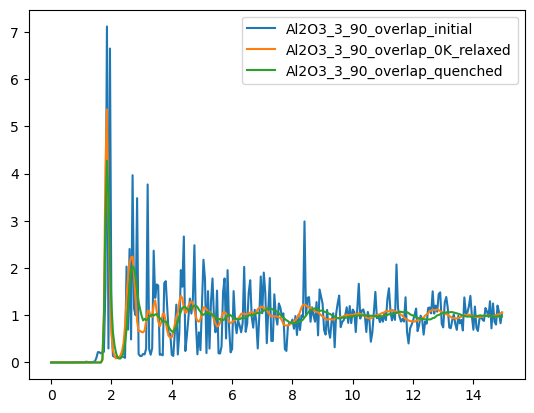

In [4]:
RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}

rdf = RDF(device=device, v=0)
fig, ax = plt.subplots()

gr_3Ds = {}

for f, nm in zip([init_file, relax_file, quench_file], ["init", "relax", "quench"]): 
    atoms = load_xyz(f, v=0)
    
    r, gr_3D = rdf.rdf(
        atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
    )
    r = r.get()
    gr_3D=gr_3D.get()
    gr_3Ds[nm] = gr_3D
    gr_3Ds['r'] = r

    ax.plot(r, gr_3D, label=f.stem)
    cp.get_default_memory_pool().free_all_blocks() 
    
ax.legend() 
plt.show()
    

In [5]:
RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}

# rdf = RDF(device=device, v=0)
# gr_3Ds = {}


loading file: Al2O3_3_90_overlap_initial.xyz
# atoms: 199560
Atoms(symbols='Al79799O119761', pbc=True, cell=[85.50786007169349, 87.11991157790018, 219.68091918519644])
Cell size (A): [ 85.50786007  87.11991158 219.68091919]
Using a max radius of 15 A
reducing dr_ind from 1 -> 0.5
reducing dr_ind from 0.5 -> 0.25
Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.122 atoms / A^3
N_max_neighbors:  10344
-- done --
Total time (h:m:s) 0:00:04.543
Center atoms per sec: 439.37

Cell size (A): [ 85.50786007  87.11991158 219.68091919]
Using a max radius of 15 A
reducing dr_ind from 1 -> 0.5
reducing dr_ind from 0.5 -> 0.25
Proceeding with dr_ind of 0.25 despite losing 1 / 2.00e+05 atoms (0.001%)
Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.122 atoms / A^3
N_max_neighbors:  10344
-- done --
Total time (h:m:s) 0:00:04.556
Center atoms per sec: 438.08

Cell size (A): [ 85.50786007  

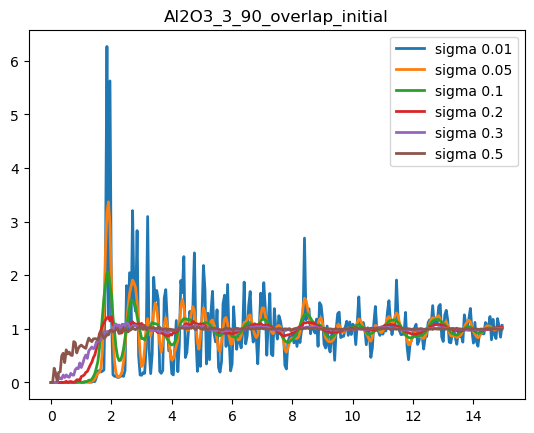

In [23]:
# sigmas = [0.01, 0.02, 0.03]
sigmas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

gr_3Dsigmas = {}

rdf = RDF(device=device, v=3)
atoms2 = load_xyz(init_file, v=3) 
for sigma in sigmas:
# for sigma in tqdm(sigmas):
    jitter = np.random.normal(loc=0, scale=sigma, size=atoms2.positions.shape)
    atoms2.positions += jitter
    atoms2.wrap() 

    rs, gr_3D_sigma = rdf.rdf(
        atoms2,
        pbcs=atoms2.pbc,
        **RDF_params, 
    )
    gr_3D_sigma = gr_3D_sigma.get()
    gr_3Dsigmas[f"gr_sigma_{sigma}"] = gr_3D_sigma 
    
    # ax.plot(rs.get(), gr_3D_sigma, label=f'sigma {sigma}', lw=2)
    # cp.cuda.Stream.null.synchronize()
    cp.get_default_memory_pool().free_all_blocks() 
    cp.get_default_pinned_memory_pool().free_all_blocks() 
gr_3Dsigmas['r'] = rs.get() 
fig, ax = plt.subplots()
# ax.plot(r, gr_3Dsigmas['init'], label='no jitter')

for sigma in sigmas: 
    ax.plot(gr_3Dsigmas['r'], gr_3Dsigmas[f"gr_sigma_{sigma}"], label=f'sigma {sigma}', lw = 2)
ax.legend()
ax.set_title(init_file.stem)
plt.show()
    

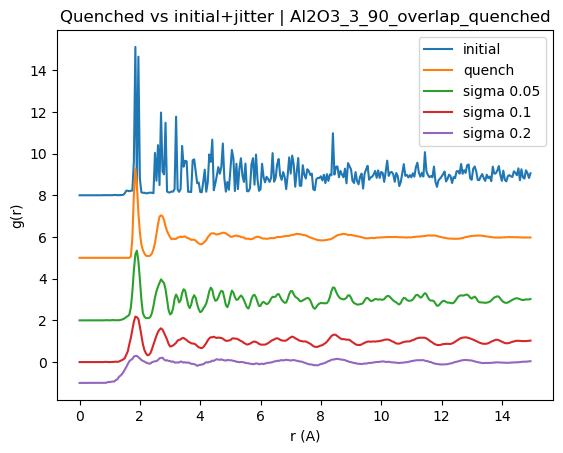

In [20]:
fig, ax = plt.subplots()
ax.plot(gr_3Ds['r'], gr_3Ds['init']+8, label='initial')
ax.plot(gr_3Ds['r'], gr_3Ds['quench']+5, label='quench')
# ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.01']+3, label='sigma 0.01')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.05']+2, label='sigma 0.05')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.1']+0, label='sigma 0.1')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.2']-1, label='sigma 0.2')
ax.legend()
ax.set_title(f"Quenched vs initial+jitter | {quench_file.stem}")
ax.set_ylabel("g(r)")
ax.set_xlabel("r (A)")
plt.show()
